# Motion-S: Hierarchical Text-to-Sign Motion Generation
**Deep Learning Project -- CLIP + Masked Transformer with Residual RVQ**

### Pipeline: Text -> CLIP Embedding -> Masked Transformer -> VAE Decode -> 3D Animation




## Section 0 -- Setup and Imports

In [1]:
import os, sys, math, random, warnings, gc, time
from pathlib import Path
from collections import Counter
from functools import partial

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
  GPU: Tesla T4


In [ ]:
# Install OPENCLIP
!pip install -q git+https://github.com/openai/OPENCLIP.git
import OPENclip

  Preparing metadata (setup.py) ... done


In [ ]:
# PATHS AND CONFIG 
KAGGLE_INPUT = Path("/kaggle/input")
DATA_BASE = KAGGLE_INPUT / "competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language"
CSV_PATH = DATA_BASE / "train.csv"
TEST_CSV = DATA_BASE / "test.csv"
VAE_PATH = KAGGLE_INPUT / "models/antonygithinji/motion-s-vae-rvq/pytorch/default/3/rvq_vae_best.pth"
LENGTH_EST_PATH = KAGGLE_INPUT / "models/antonygithinji/motion-s-length-estimator/pytorch/default/1/length_estimator_best.pth"
OUTPUT_ROOT = Path("/kaggle/working")

TOKEN_COLS = ["base_tokens", "residual_1", "residual_2",
              "residual_3", "residual_4", "residual_5"]
VOCAB = 512
MIN_LEN, MAX_LEN = 40, 800

CONFIG = {
    'latent_dim': 384, 'ff_size': 1024, 'num_layers': 8,
    'num_heads': 6, 'dropout': 0.1, 'cond_drop_prob': 0.2,
    'max_token_len': 500, 'min_token_len': 6, 'text_source': 'both',
    'batch_size': 32, 'grad_accum': 4, 'lr': 2e-4,
    'weight_decay': 0.01, 'warmup_epochs': 12, 'epochs': 120,
    'full_mask_prob': 0.4, 'label_smoothing': 0.05,
    'residual_start_epoch': 30, 'res_lr': 1e-4,
    'res_weight_decay': 0.01, 'res_prob': 1.0,
    'gen_timesteps': 18, 'gen_cond_scale': 5.0,
    'gen_temperature': 1.0, 'gen_topk_thres': 0.9,
}

VAE_CONFIG = {'num_embeddings': 512, 'latent_dim': 256, 'num_quantizers': 6}

print("Configuration loaded")

Configuration loaded


---
## Section 1 -- Dataset Loading and EDA
**Deliverable 1: Dataset preprocessing and understanding**

In [4]:
train_df = pd.read_csv(CSV_PATH)
test_df = pd.read_csv(TEST_CSV)

print(f"Train: {train_df.shape[0]} rows, {train_df.shape[1]} cols")
print(f"Test : {test_df.shape[0]} rows, {test_df.shape[1]} cols")
print(f"Train columns: {train_df.columns.tolist()}")
print(f"Test  columns: {test_df.columns.tolist()}")
train_df.head(3)

Train: 12467 rows, 10 cols
Test : 3000 rows, 3 cols
Train columns: ['id', 'sentence', 'gloss', 'bvh_path', 'base_tokens', 'residual_1', 'residual_2', 'residual_3', 'residual_4', 'residual_5']
Test  columns: ['id', 'sentence', 'gloss']


,id,sentence,gloss,bvh_path,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,1000648,Don't keep me on tenterhooks!,KEEP ME TENTHOOK//,dataset/1000648/1000648.bvh,379 295 376 376 376 376 376 376 133 133 376 37...,339 441 88 87 87 87 88 288 405 333 333 248 212...,406 183 8 301 476 6 169 255 452 462 66 255 463...,315 424 330 104 364 104 142 142 166 353 353 10...,64 32 15 326 466 20 229 456 71 71 71 390 20 90...,306 376 367 367 133 235 276 350 367 350 437 36...
1,1002815,"I like to be home, that way I can work on my s...",ME LIKE HOME WORK STORY FINISH//,dataset/1002815/1002815.bvh,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
2,1003115,Can I stay here tonight?,STAY HERE TONIGHT ME?,dataset/1003115/1003115.bvh,379 185 185 185 185 185 185 185 185 185 185 18...,339 441 87 87 88 88 88 288 308 88 325 483 483 ...,396 171 11 11 211 211 321 430 464 464 283 267 ...,65 449 376 191 503 503 142 166 384 143 384 348...,64 230 328 411 349 71 424 71 498 456 234 85 34...,306 201 367 6 266 406 123 71 343 428 38 404 37...


In [ ]:
#  EDA 
text_col = "gloss" if "gloss" in train_df.columns else "sentence"
print(f"Text column: '{text_col}'")

# Drop NaN token rows
nan_count = train_df[TOKEN_COLS[0]].isna().sum()
print(f"NaN rows in base_tokens: {nan_count}/{len(train_df)}")
train_df = train_df.dropna(subset=TOKEN_COLS).reset_index(drop=True)
print(f"After cleanup: {len(train_df)} rows")

train_df["text_len"] = train_df[text_col].astype(str).apply(lambda x: len(x.split()))
train_df["token_len"] = train_df["base_tokens"].astype(str).apply(
    lambda x: len([t for t in x.split() if t not in ('nan', '')]))

all_words = " ".join(train_df[text_col].astype(str).tolist()).upper().split()
word_freq = Counter(all_words)

print(f"\nText length: mean={train_df['text_len'].mean():.1f}, max={train_df['text_len'].max()}")
print(f"Token length: mean={train_df['token_len'].mean():.1f}, max={train_df['token_len'].max()}")
print(f"Vocabulary: {len(word_freq)} unique tokens")
print(f"Top 10: {word_freq.most_common(10)}")

# Token value check
sample_tokens = []
for idx in range(min(200, len(train_df))):
    for t in str(train_df["base_tokens"].iloc[idx]).split():
        try: sample_tokens.append(int(float(t)))
        except: pass
if sample_tokens:
    print(f"Token range: [{min(sample_tokens)}, {max(sample_tokens)}]")

Text column: 'gloss'
NaN rows in base_tokens: 4/12467
After cleanup: 12463 rows

Text length: mean=4.8, max=50
Token length: mean=108.1, max=1853
Vocabulary: 5883 unique tokens
Top 10: [('ME', 4112), ('HE', 1372), ('SHE', 847), ('THAT', 670), ('THIS', 663), ('NOT', 595), ('MY', 506), ('I', 500), ('ME//', 494), ('DO', 488)]
Token range: [0, 510]


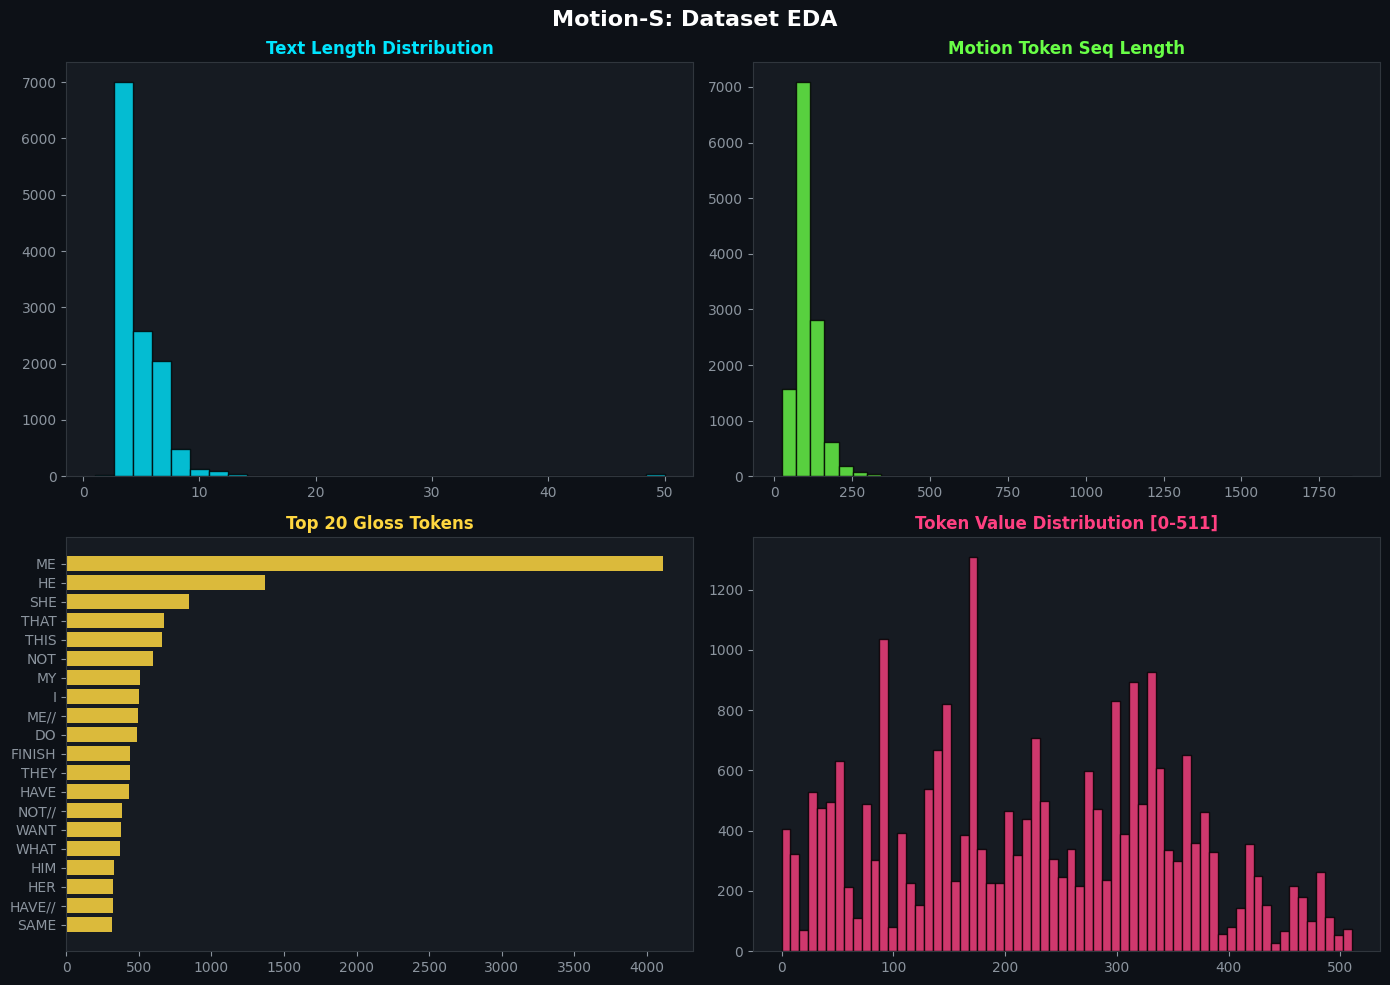

In [ ]:
# EDA Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("Motion-S: Dataset EDA", color="white", fontsize=16, fontweight="bold")
C = {"panel": "#161b22", "cyan": "#00e5ff", "pink": "#ff4081", "green": "#69ff47", "gold": "#ffd740"}

for ax in axes.flat:
    ax.set_facecolor(C["panel"])
    for s in ax.spines.values(): s.set_edgecolor("#30363d")
    ax.tick_params(colors="#8b949e")

axes[0,0].hist(train_df["text_len"], bins=30, color=C["cyan"], alpha=0.8, edgecolor="black")
axes[0,0].set_title("Text Length Distribution", color=C["cyan"], fontweight="bold")

axes[0,1].hist(train_df["token_len"], bins=40, color=C["green"], alpha=0.8, edgecolor="black")
axes[0,1].set_title("Motion Token Seq Length", color=C["green"], fontweight="bold")

top20 = word_freq.most_common(20)
axes[1,0].barh([w for w,_ in top20][::-1], [c for _,c in top20][::-1], color=C["gold"], alpha=0.85)
axes[1,0].set_title("Top 20 Gloss Tokens", color=C["gold"], fontweight="bold")

if sample_tokens:
    axes[1,1].hist(sample_tokens, bins=64, color=C["pink"], alpha=0.8, edgecolor="black")
    axes[1,1].set_title("Token Value Distribution [0-511]", color=C["pink"], fontweight="bold")

plt.tight_layout(); plt.show()

---
## Section 2 -- BVH Motion Data Understanding
**Deliverable 4: Visualization of ground truth motion using BVH files**

BVH (Biovision Hierarchy) is a motion capture format with:
- HIERARCHY: Tree of joints with offsets and rotation channels
- MOTION: Per-frame rotation/position values

In this competition, raw motion has been compressed:
```
668-dim SMPL-X features -> VAE Encoder -> 6 RVQ token layers (codebook=512)
```

Parsed 14 joints


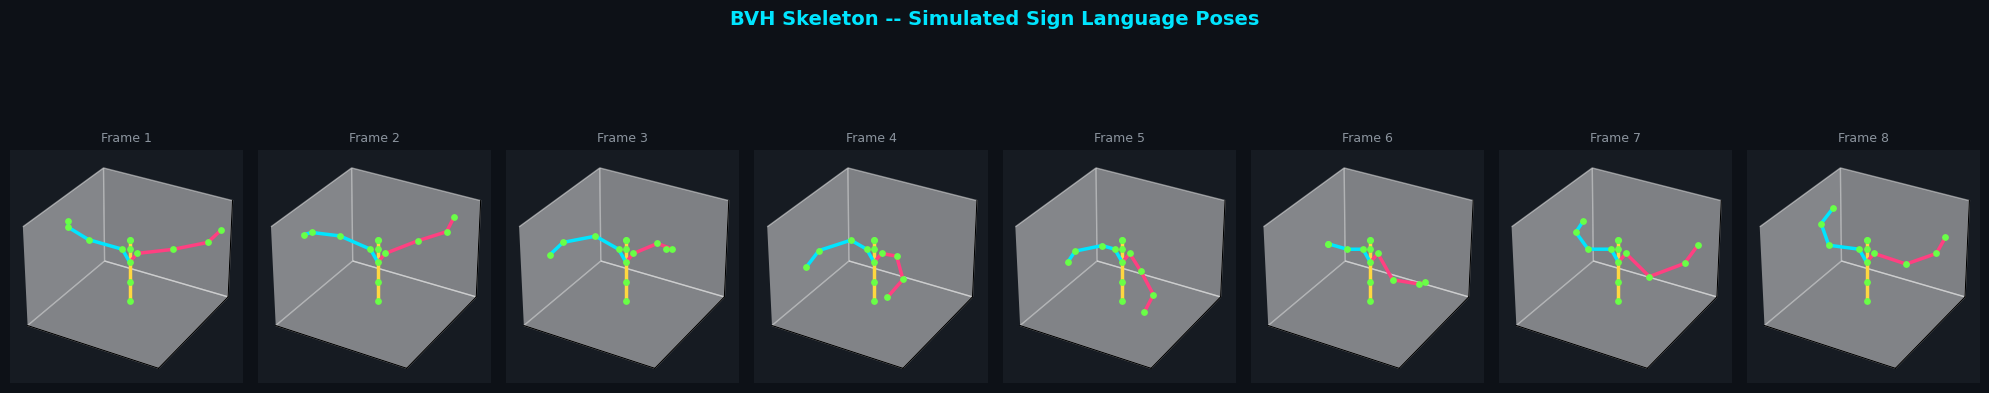

BVH skeleton visualization complete


In [7]:
class BVHJoint:
    def __init__(self, name, parent=None):
        self.name, self.parent, self.children = name, parent, []
        self.offset, self.channels = np.zeros(3), []

def parse_bvh(text):
    joints, stack, cur = [], [], None
    for line in text.strip().split("\n"):
        line = line.strip()
        if line.startswith(("ROOT", "JOINT")):
            j = BVHJoint(line.split()[-1], stack[-1] if stack else None)
            if j.parent: j.parent.children.append(j)
            joints.append(j); cur = j
        elif line.startswith("End Site"):
            j = BVHJoint(f"{cur.name}_End", cur)
            cur.children.append(j); joints.append(j); cur = j
        elif line.startswith("OFFSET"):
            cur.offset = np.array([float(x) for x in line.split()[1:4]])
        elif line.startswith("CHANNELS"):
            cur.channels = line.split()[2:]
        elif line == "{": stack.append(cur)
        elif line == "}" and stack: cur = stack.pop()
    return joints

SKEL = """
HIERARCHY
ROOT Hips
{
    OFFSET 0.0 0.0 0.0
    CHANNELS 6 Xposition Yposition Zposition Zrotation Xrotation Yrotation
    JOINT Spine
    {
        OFFSET 0.0 18.0 0.0
        CHANNELS 3 Zrotation Xrotation Yrotation
        JOINT Chest
        {
            OFFSET 0.0 18.0 0.0
            CHANNELS 3 Zrotation Xrotation Yrotation
            JOINT Neck
            {
                OFFSET 0.0 12.0 0.0
                CHANNELS 3 Zrotation Xrotation Yrotation
                JOINT Head
                {
                    OFFSET 0.0 8.0 0.0
                    CHANNELS 3 Zrotation Xrotation Yrotation
                    End Site
                    { OFFSET 0.0 8.0 0.0 }
                }
            }
            JOINT LeftShoulder
            {
                OFFSET 8.0 10.0 0.0
                CHANNELS 3 Zrotation Xrotation Yrotation
                JOINT LeftElbow
                {
                    OFFSET 25.0 0.0 0.0
                    CHANNELS 3 Zrotation Xrotation Yrotation
                    JOINT LeftWrist
                    {
                        OFFSET 22.0 0.0 0.0
                        CHANNELS 3 Zrotation Xrotation Yrotation
                        End Site
                        { OFFSET 10.0 0.0 0.0 }
                    }
                }
            }
            JOINT RightShoulder
            {
                OFFSET -8.0 10.0 0.0
                CHANNELS 3 Zrotation Xrotation Yrotation
                JOINT RightElbow
                {
                    OFFSET -25.0 0.0 0.0
                    CHANNELS 3 Zrotation Xrotation Yrotation
                    JOINT RightWrist
                    {
                        OFFSET -22.0 0.0 0.0
                        CHANNELS 3 Zrotation Xrotation Yrotation
                        End Site
                        { OFFSET -10.0 0.0 0.0 }
                    }
                }
            }
        }
    }
}"""

joints = parse_bvh(SKEL)
print(f"Parsed {len(joints)} joints")

# Simulate sign motion and visualize
fig = plt.figure(figsize=(20, 5))
fig.patch.set_facecolor("#0d1117")
fig.suptitle("BVH Skeleton -- Simulated Sign Language Poses", color="#00e5ff", fontsize=14, fontweight="bold")

for fi in range(8):
    t = fi / 8 * 2 * np.pi
    positions = {}
    for j in joints:
        off = j.offset.copy()
        if "LeftElbow" in j.name: off[1] += 15*np.sin(t); off[2] += 10*np.cos(t)
        elif "LeftWrist" in j.name: off[1] += 8*np.sin(t*1.5); off[2] += 12*np.cos(t*1.3)
        elif "RightElbow" in j.name: off[1] += 12*np.sin(t+np.pi/3); off[2] -= 8*np.cos(t)
        elif "RightWrist" in j.name: off[1] += 6*np.cos(t*1.2); off[2] -= 10*np.sin(t*0.8)
        positions[j.name] = (positions[j.parent.name] + off) if (j.parent and j.parent.name in positions) else off.copy()

    ax = fig.add_subplot(1, 8, fi+1, projection="3d")
    ax.set_facecolor("#161b22"); ax.set_title(f"Frame {fi+1}", color="#8b949e", fontsize=9)
    for j in joints:
        if j.parent and j.parent.name in positions and j.name in positions:
            p1, p2 = positions[j.parent.name], positions[j.name]
            c = "#ff4081" if "Left" in j.name else "#00e5ff" if "Right" in j.name else "#ffd740"
            ax.plot([p1[0],p2[0]], [p1[2],p2[2]], [p1[1],p2[1]], color=c, lw=2.5)
    for pos in positions.values():
        ax.scatter(pos[0], pos[2], pos[1], c="#69ff47", s=15)
    ax.set_xlim(-70,70); ax.set_ylim(-30,30); ax.set_zlim(-10,80)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout(); plt.show()
print("BVH skeleton visualization complete")

---
## Section 3 -- Model Architecture
**Deliverable 2: Model that maps text -> motion tokens**

### Why Autoregressive Transformer?
1. **Causal generation**: Tokens are generated left-to-right, preserving the temporal
   ordering inherent in sign language motion sequences
2. **CLIP conditioning**: Pre-trained CLIP ViT-B/32 provides rich text semantics via cross-attention
3. **Proven architecture**: GPT-style decoders are well-understood and stable to train
4. **Hierarchical RVQ**: Separate base + residual models let each specialize
5. **Top-k sampling**: Temperature-controlled sampling produces diverse, realistic outputs

### Architecture
```
Text -> CLIP ViT-B/32 -> TextContextualizer (2-layer Transformer)
                                    |
                              Cross-Attention
                                    |
[BOS] t1 t2 ... -> Embedding -> Causal Self-Attn -> Cross-Attn -> FFN -> Softmax(512)
                                    |
Output: t1 t2 t3 ... tN (autoregressive, left-to-right)
```

In [ ]:
# CLIP TEXT ENCODER 
class CLIPTextEncoder(nn.Module):
    def __init__(self, version="ViT-B/32", dev="cuda", freeze=True):
        super().__init__()
        self.model, _ = clip.load(version, device=dev)
        self.model = self.model.float()
        self.device = dev
        self.embed_dim = self.model.text_projection.shape[1]
        if freeze:
            for p in self.model.parameters(): p.requires_grad = False
            self.model.eval()
        self._cache = {}

    def _warm(self, texts):
        miss = [i for i, t in enumerate(texts) if t not in self._cache]
        if not miss: return
        mt = [texts[i] for i in miss]
        tok = clip.tokenize(mt, truncate=True).to(self.device)
        with torch.no_grad():
            x = self.model.token_embedding(tok) + self.model.positional_embedding
            x = self.model.transformer(x.permute(1,0,2)).permute(1,0,2)
            x = self.model.ln_final(x)
            mask = (tok != 0).float()
            e = x[torch.arange(len(mt)), tok.argmax(-1)] @ self.model.text_projection
            e = e / e.norm(dim=-1, keepdim=True)
            for j, i in enumerate(miss):
                self._cache[texts[i]] = (x[j], mask[j], e[j])
        # Evict old entries if cache gets too large
        if len(self._cache) > 16000:
            protected = set(texts)
            for k in list(self._cache.keys()):
                if k not in protected and len(self._cache) > 12000:
                    del self._cache[k]

    def encode_text(self, texts):
        self._warm(texts)
        return torch.stack([self._cache[t][2] for t in texts])

    def encode_text_tokens(self, texts):
        self._warm(texts)
        return (torch.stack([self._cache[t][0] for t in texts]),
                torch.stack([self._cache[t][1] for t in texts]))

    def forward(self, texts, tokens=False):
        return self.encode_text_tokens(texts) if tokens else self.encode_text(texts)

In [ ]:
# HELPER MODULES 
def topk_filter(logits, th=0.9, d=-1):
    k = max(1, int((1 - th) * logits.shape[d]))
    v, i = logits.topk(k, d)
    out = torch.full_like(logits, float('-inf'))
    out.scatter_(d, i, v)
    return out

def lens_mask(lens, ml):
    return torch.arange(ml, device=lens.device).expand(len(lens), ml) < lens.unsqueeze(1)

class PositionalEncoding(nn.Module):
    def __init__(self, d, p=0.1, ml=1000):
        super().__init__()
        self.drop = nn.Dropout(p)
        pe = torch.zeros(ml, d)
        pos = torch.arange(ml).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, ml, d)

    def forward(self, x):
        # x: (B, T, d)
        return self.drop(x + self.pe[:, :x.shape[1]])

In [ ]:
#  AUTOREGRESSIVE TRANSFORMER DECODER (base token generation) 
class GPTDecoderLayer(nn.Module):
    """Single decoder layer: causal self-attention + cross-attention to text + FFN."""
    def __init__(self, d_model, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        # Causal self-attention
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.self_norm = nn.LayerNorm(d_model)
        self.self_drop = nn.Dropout(dropout)
        # Cross-attention to text
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)
        self.cross_drop = nn.Dropout(dropout)
        # Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(ff_dim, d_model), nn.Dropout(dropout))
        self.ff_norm = nn.LayerNorm(d_model)

    def forward(self, x, text_ctx, causal_mask=None, text_pad_mask=None, tgt_pad_mask=None):
        # Self-attention (causal)
        r = x; x = self.self_norm(x)
        x, _ = self.self_attn(x, x, x, attn_mask=causal_mask, key_padding_mask=tgt_pad_mask)
        x = r + self.self_drop(x)
        # Cross-attention to text context
        r = x; x = self.cross_norm(x)
        x, _ = self.cross_attn(x, text_ctx, text_ctx, key_padding_mask=text_pad_mask)
        x = r + self.cross_drop(x)
        # Feed-forward
        r = x; x = r + self.ff(self.ff_norm(x))
        return x

class AutoregressiveTransformer(nn.Module):
    """GPT-style autoregressive decoder conditioned on CLIP text embeddings.

    Training: teacher forcing with causal mask.
    Generation: left-to-right token-by-token with top-k sampling.
    """
    def __init__(self, num_tokens=512, code_dim=256, latent_dim=384, ff_size=1024,
                 num_layers=8, num_heads=6, dropout=0.1, clip_dim=512,
                 clip_version="ViT-B/32", cond_drop_prob=0.2, device="cuda", max_seq_len=600):
        super().__init__()
        self.nt = num_tokens
        self.ld = latent_dim
        self.cdp = cond_drop_prob
        self.dev = device
        self.bos_id = num_tokens  

        # Token embedding 
        self.tok_embed = nn.Embedding(num_tokens + 1, latent_dim)
        self.pos_enc = PositionalEncoding(latent_dim, dropout, max_seq_len)

        # Text encoder 
        self.tenc = CLIPTextEncoder(clip_version, device, freeze=True)
        self.tcontx = TextContextualizer(clip_dim, latent_dim, dropout=dropout)

        # Decoder layers
        self.layers = nn.ModuleList([
            GPTDecoderLayer(latent_dim, num_heads, ff_size, dropout)
            for _ in range(num_layers)])
        self.norm = nn.LayerNorm(latent_dim)

        # Output head
        self.output_proj = nn.Linear(latent_dim, num_tokens)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                m.weight.data.normal_(0, 0.02)
                if isinstance(m, nn.Linear) and m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.LayerNorm):
                m.bias.data.zero_(); m.weight.data.fill_(1.0)

    def dropc(self, c, force=False):
        """Classifier-free guidance: randomly drop conditioning during training."""
        if force: return torch.zeros_like(c)
        if not self.training or self.cdp == 0: return c
        m = torch.bernoulli(torch.full((c.shape[0],), self.cdp, device=c.device))
        return c * (1 - m.view(-1, 1, 1))

    def encode_text(self, texts):
        te, tm = self.tenc(texts, tokens=True)
        text_pad = (tm == 0)
        text_ctx = self.tcontx(te, text_pad)
        return text_ctx, text_pad

    def _causal_mask(self, T, device):
        """Upper-triangular causal mask: position i can only attend to 0..i."""
        return torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()

    def forward(self, motion_ids, texts, m_lens, label_smoothing=0.05):
        """Training forward pass with teacher forcing.

        Args:
            motion_ids: (B, T) ground truth token IDs [0..511]
            texts: list of B text strings
            m_lens: (B,) actual sequence lengths
            label_smoothing: label smoothing factor
        Returns:
            loss, predictions, accuracy
        """
        B, T = motion_ids.shape
        dev = motion_ids.device
        valid = lens_mask(m_lens, T)  # (B, T)

        # Encode text
        text_ctx, text_pad = self.encode_text(texts)
        text_ctx = self.dropc(text_ctx)

        # Build input: [BOS, t1, t2, ..., tN-1] (shift right)
        bos = torch.full((B, 1), self.bos_id, dtype=torch.long, device=dev)
        input_ids = torch.cat([bos, motion_ids[:, :-1]], dim=1)  # (B, T)

        # Embed tokens
        x = self.tok_embed(input_ids)  # (B, T, ld)
        x = self.pos_enc(x)

        # Causal mask
        causal_mask = self._causal_mask(T, dev)
        tgt_pad = ~valid

        # Pass through decoder layers
        for layer in self.layers:
            x = layer(x, text_ctx, causal_mask, text_pad, tgt_pad)
        x = self.norm(x)

        # Project to vocabulary
        logits = self.output_proj(x)

        # Loss: only on valid positions
        targets = motion_ids.clone()
        targets[~valid] = -100  # ignore padding in loss

        loss = F.cross_entropy(
            logits.reshape(-1, self.nt), targets.reshape(-1),
            ignore_index=-100, label_smoothing=label_smoothing)

        pred = logits.argmax(-1)
        acc = ((pred == motion_ids) & valid).sum().float() / valid.sum().clamp(min=1)
        return loss, pred, acc.item()

    @torch.no_grad()
    def generate(self, texts, m_lens, temperature=1.0, topk_thres=0.9, cond_scale=5.0):
        """Autoregressive generation with classifier-free guidance.

        Args:
            texts: list of B text strings
            m_lens: (B,) target sequence lengths
            temperature: sampling temperature
            topk_thres: top-k filtering threshold
            cond_scale: classifier-free guidance scale
        Returns:
            (B, max_len) tensor of generated token IDs
        """
        self.eval()
        B = len(texts)
        dev = next(self.parameters()).device
        ml = m_lens.max().item()

        # Encode text (with and without conditioning for CFG)
        text_ctx, text_pad = self.encode_text(texts)
        text_ctx_null = torch.zeros_like(text_ctx)

        # Start with BOS
        generated = torch.full((B, 1), self.bos_id, dtype=torch.long, device=dev)

        for step in range(ml):
            T = generated.shape[1]
            x = self.pos_enc(self.tok_embed(generated))
            causal_mask = self._causal_mask(T, dev)

            # Conditional pass
            xc = x.clone()
            for layer in self.layers:
                xc = layer(xc, text_ctx, causal_mask, text_pad, None)
            logits_cond = self.output_proj(self.norm(xc))[:, -1, :]  # (B, nt)

            # Unconditional pass (for CFG)
            xu = x.clone()
            for layer in self.layers:
                xu = layer(xu, text_ctx_null, causal_mask, text_pad, None)
            logits_uncond = self.output_proj(self.norm(xu))[:, -1, :]

            # Classifier-free guidance
            logits = logits_uncond + cond_scale * (logits_cond - logits_uncond)

            # Top-k + temperature sampling
            filtered = topk_filter(logits, topk_thres)
            probs = F.softmax(filtered / temperature, dim=-1)
            next_token = torch.multinomial(probs, 1)  # (B, 1)

            generated = torch.cat([generated, next_token], dim=1)

        # Remove BOS, keep only generated tokens
        output = generated[:, 1:]  # (B, ml)

        # Mask positions beyond each sequence's target length
        valid = lens_mask(m_lens, ml)
        output[~valid] = -1

        return output

    def params_no_clip(self):
        return [p for n, p in self.named_parameters() if 'tenc' not in n]

In [ ]:
#  HIERARCHICAL TRANSFORMER (layers 1-5, single-pass conditioned on previous layers) 
class HierarchicalTransformer(nn.Module):
    """Generates hierarchical RVQ layers 1-5, conditioned on all previous layers
    through VQ-VAE codebook embeddings and text context."""

    def __init__(self, nt, cd, nq, ld=384, ff=1024, nl=8, nh=6, dp=0.1,
                 clip_dim=512, clip_ver="ViT-B/32", cdp=0.1, dev="cuda", msl=600):
        super().__init__()
        self.nt, self.cd, self.nq, self.ld, self.cdp, self.dev = nt, cd, nq, ld, cdp, dev
        self.pid = nt  # padding ID
        self.te = nn.Embedding(nt + 1, cd)
        self.le = nn.Embedding(nq - 1, ld)  # layer embedding
        self.inp = nn.Linear(cd, ld)
        self.pos = PositionalEncoding(ld, dp, msl)

        self.tenc = CLIPTextEncoder(clip_ver, dev, freeze=True)
        self.tcontx = TextContextualizer(clip_dim, ld, dropout=dp)

        enc_layer = nn.TransformerEncoderLayer(ld, nh, ff, dp, 'gelu', batch_first=True)
        self.trans = nn.TransformerEncoder(enc_layer, nl)

        self.out_norm = nn.LayerNorm(ld)
        self.out_proj = nn.Linear(ld, nt)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                m.weight.data.normal_(0, 0.02)
                if isinstance(m, nn.Linear) and m.bias is not None: m.bias.data.zero_()
            elif isinstance(m, nn.LayerNorm): m.bias.data.zero_(); m.weight.data.fill_(1.0)

    def dropc(self, c, force=False):
        if force: return torch.zeros_like(c)
        if not self.training or self.cdp == 0: return c
        m = torch.bernoulli(torch.full((c.shape[0],), self.cdp, device=c.device))
        return c * (1 - m.view(-1, 1, 1))

    def encode_text(self, texts):
        te, tm = self.tenc(texts, tokens=True)
        return self.tcontx(te, tm == 0), (tm == 0)

    def embed_prev(self, prev_toks, vq):
        """Sum VQ-VAE codebook embeddings from all previous layers."""
        B, sl = prev_toks[0].shape
        emb = torch.zeros(B, sl, self.cd, device=prev_toks[0].device)
        for i, toks in enumerate(prev_toks):
            cb = vq.rvq.quantizers[i].embedding  # (cd, nt)
            flat = toks.reshape(-1).clamp(0, self.nt - 1)
            emb += cb[:, flat].t().reshape(B, sl, self.cd)
        return emb

    def forward(self, prev_toks, targ, li, texts, mlens, vq):
        B, sl = targ.shape
        valid = lens_mask(mlens, sl); pad = ~valid
        targ = torch.where(valid, targ, self.pid)

        # Text context
        ce, cpad = self.encode_text(texts)
        ce = self.dropc(ce)

        # Embed previous layers and add layer embedding
        p_emb = self.inp(self.embed_prev(prev_toks, vq))
        p_emb = p_emb + self.le(torch.tensor(li - 1, device=p_emb.device))
        p_emb = self.pos(p_emb)

        # Concatenate text context + motion embeddings
        seq = torch.cat([ce, p_emb], dim=1)  # (B, T_text + T_motion, ld)
        pad_mask = torch.cat([cpad, pad], dim=1)

        out = self.trans(seq, src_key_padding_mask=pad_mask)
        out = out[:, ce.shape[1]:, :]  # take motion part only

        logits = self.out_proj(self.out_norm(F.gelu(out)))  # (B, sl, nt)

        loss = F.cross_entropy(
            logits.reshape(-1, self.nt), targ.reshape(-1), ignore_index=self.pid)
        acc = ((logits.argmax(-1) == targ) & valid).sum().float() / valid.sum().clamp(min=1)
        return loss, logits.argmax(-1), acc.item()

    @torch.no_grad()
    def generate_layer(self, prev_toks, li, texts, mlens, vq, cs=5.0, temp=1.0, th=0.9):
        self.eval()
        B = len(texts); sl = prev_toks[0].shape[1]
        valid = lens_mask(mlens, sl); pad = ~valid

        p_emb = self.inp(self.embed_prev(prev_toks, vq))
        p_emb = p_emb + self.le(torch.tensor(li - 1, device=p_emb.device))
        p_emb = self.pos(p_emb)

        ce, cpad = self.encode_text(texts)

        # Conditional
        seq_c = torch.cat([ce, p_emb], dim=1)
        out_c = self.trans(seq_c, src_key_padding_mask=torch.cat([cpad, pad], dim=1))
        logits_c = self.out_proj(self.out_norm(F.gelu(out_c[:, ce.shape[1]:])))

        # Unconditional (for CFG)
        ce_null = torch.zeros_like(ce)
        seq_u = torch.cat([ce_null, p_emb], dim=1)
        out_u = self.trans(seq_u, src_key_padding_mask=torch.cat([cpad, pad], dim=1))
        logits_u = self.out_proj(self.out_norm(F.gelu(out_u[:, ce.shape[1]:])))

        logits = logits_u + cs * (logits_c - logits_u)
        probs = F.softmax(topk_filter(logits, th) / temp, -1)
        ids = torch.multinomial(probs.view(-1, self.nt), 1).view(B, sl)
        return torch.where(valid, ids, self.pid)

    def params_no_clip(self):
        return [p for n, p in self.named_parameters() if 'tenc' not in n]

In [ ]:
# VQ-VAE (codebook embedding lookup for residual model) 
class VectorQuantizer(nn.Module):
    def __init__(self, ne=512, ed=256):
        super().__init__()
        self.embedding = nn.Parameter(torch.randn(ed, ne))

class ResidualVectorQuantizer(nn.Module):
    def __init__(self, nq=6, ne=512, ed=256):
        super().__init__()
        self.num_quantizers = nq
        self.quantizers = nn.ModuleList([VectorQuantizer(ne, ed) for _ in range(nq)])

class RVQVAE(nn.Module):
    def __init__(self, rvq, dr=4):
        super().__init__()
        self.encoder = None; self.decoder = None; self.rvq = rvq
        self.num_quantizers = rvq.num_quantizers; self.downsampling_ratio = dr

def load_vae(path, dev='cuda'):
    ckpt = torch.load(path, map_location=dev, weights_only=False)
    state = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
    cfg = ckpt.get('model_config', ckpt.get('config', {}))
    rvq = ResidualVectorQuantizer(cfg.get('num_quantizers',6), cfg.get('num_embeddings',512), cfg.get('latent_dim',256))
    rvq.load_state_dict({k.replace('rvq.',''):v for k,v in state.items() if k.startswith('rvq.')}, strict=False)
    vae = RVQVAE(rvq, cfg.get('downsampling_ratio', 4))
    vae.to(dev).eval()
    print(f"VAE loaded: {cfg.get('num_quantizers',6)} quantizers, {cfg.get('num_embeddings',512)} embeddings")
    return vae

In [ ]:
#  LENGTH ESTIMATOR 
class LengthEstimator(nn.Module):
    def __init__(self, clip_dim=512, num_bins=50, hd=512, mn=10, mx=200, dp=0.2):
        super().__init__()
        self.num_bins, self.min_tokens, self.max_tokens = num_bins, mn, mx
        self.bin_size = (mx - mn) / (num_bins - 1)
        self.net = nn.Sequential(
            nn.Linear(clip_dim, hd), nn.LayerNorm(hd), nn.LeakyReLU(0.2, True), nn.Dropout(dp),
            nn.Linear(hd, hd//2), nn.LayerNorm(hd//2), nn.LeakyReLU(0.2, True), nn.Dropout(dp),
            nn.Linear(hd//2, hd//4), nn.LayerNorm(hd//4), nn.LeakyReLU(0.2, True),
            nn.Linear(hd//4, num_bins))

    def forward(self, x): return self.net(x)

    @torch.no_grad()
    def estimate_lengths(self, texts, clip_model, mode='mean'):
        self.eval(); emb = clip_model(texts)
        logits = self.forward(emb)
        probs = F.softmax(logits, -1)
        bi = torch.arange(self.num_bins, device=logits.device, dtype=torch.float)
        bins = (probs * bi).sum(-1).round().long()
        return (self.min_tokens + bins.float() * self.bin_size).round().long().tolist()

print("All model classes defined (AutoregressiveTransformer + ResidualTransformer)")

All model classes defined (AutoregressiveTransformer + ResidualTransformer)


---
## Section 4 -- Data Preparation and Training
Training both base (AutoregressiveTransformer) and residual models.

In [ ]:
#  PARSE DATA 
def parse_tokens(s):
    if pd.isna(s): return np.array([])
    return np.array([int(x) for x in str(s).split() if x.strip()], dtype=np.int32)

for c in TOKEN_COLS:
    train_df[c] = train_df[c].apply(parse_tokens)

token_data = {}
for _, r in train_df.iterrows():
    sid = str(r['id']); base = r['base_tokens']
    if len(base) == 0: continue
    cl = len(base); layers = []
    for c in TOKEN_COLS:
        t = r[c]
        if len(t) == 0: t = np.zeros(cl, dtype=np.int32)
        elif len(t) < cl: t = np.pad(t, (0, cl - len(t)), constant_values=0)
        else: t = t[:cl]
        layers.append(t)
    token_data[sid] = {'tokens': np.stack(layers), 'sentence': r['sentence'], 'gloss': r['gloss']}

print(f"Parsed {len(token_data)} valid samples")

# Build retrieval index for hybrid submission
train_glosses = {}
for sid, v in token_data.items():
    g = str(v.get('gloss', '')).strip().lower()
    if g and g != 'nan':
        if g not in train_glosses: train_glosses[g] = []
        train_glosses[g].append(sid)
print(f"Indexed {len(train_glosses)} unique glosses for retrieval")

Parsed 12463 valid samples
Indexed 12364 unique glosses for retrieval


In [ ]:
#  DATASET 
class TokenDataset(Dataset):
    def __init__(self, data, src='both', max_len=500, min_len=6):
        self.items = []
        for sid, v in data.items():
            toks = v['tokens']; tl = toks.shape[1]
            if tl < min_len or tl > max_len: continue
            sent = str(v.get('sentence', '')); gl = str(v.get('gloss', ''))
            if src == 'both': text = f"{sent} {gl}"
            elif src == 'gloss': text = gl
            else: text = sent
            self.items.append((text, torch.tensor(toks, dtype=torch.long), tl))
        print(f"TokenDataset: {len(self.items)} samples (len {min_len}-{max_len}), src='{src}'")

    def __len__(self): return len(self.items)
    def __getitem__(self, idx): return self.items[idx]

# Train/val split
keys = list(token_data.keys()); random.shuffle(keys)
split = int(len(keys) * 0.9)
train_d = {k: token_data[k] for k in keys[:split]}
val_d = {k: token_data[k] for k in keys[split:]}

train_ds = TokenDataset(train_d, CONFIG['text_source'], CONFIG['max_token_len'], CONFIG['min_token_len'])
val_ds = TokenDataset(val_d, CONFIG['text_source'], CONFIG['max_token_len'], CONFIG['min_token_len'])

def collate(batch):
    texts = [b[0] for b in batch]
    max_l = max(b[2] for b in batch)
    padded = []
    for _, toks, tl in batch:
        if toks.shape[1] < max_l:
            padded.append(torch.cat([toks, torch.zeros(6, max_l - toks.shape[1], dtype=torch.long)], dim=1))
        else:
            padded.append(toks[:, :max_l])
    return texts, torch.stack(padded), torch.tensor([b[2] for b in batch], dtype=torch.long)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
                        collate_fn=collate, pin_memory=True)

TokenDataset: 11180 samples (len 6-500), src='both'
TokenDataset: 1242 samples (len 6-500), src='both'


In [ ]:
# BUILD MODELS 
vq_model = load_vae(VAE_PATH, device)
msl = CONFIG['max_token_len'] + 10  # extra room for BOS

transformer = AutoregressiveTransformer(
    num_tokens=VAE_CONFIG['num_embeddings'], code_dim=VAE_CONFIG['latent_dim'],
    latent_dim=CONFIG['latent_dim'], ff_size=CONFIG['ff_size'],
    num_layers=CONFIG['num_layers'], num_heads=CONFIG['num_heads'],
    dropout=CONFIG['dropout'], clip_dim=512, clip_version="ViT-B/32",
    cond_drop_prob=CONFIG['cond_drop_prob'], device=device, max_seq_len=msl
).to(device)

res_model = ResidualTransformer(
    VAE_CONFIG['num_embeddings'], VAE_CONFIG['latent_dim'],
    VAE_CONFIG['num_quantizers'], CONFIG['latent_dim'], CONFIG['ff_size'],
    CONFIG['num_layers'], CONFIG['num_heads'], CONFIG['dropout'], 512,
    "ViT-B/32", CONFIG['cond_drop_prob'], "cpu", msl
)

tp = sum(p.numel() for p in transformer.params_no_clip())
rp = sum(p.numel() for p in res_model.params_no_clip())
print(f"AutoregressiveTransformer: {tp:,} trainable params")
print(f"ResidualTransformer: {rp:,} trainable params")

VAE loaded: 6 quantizers, 512 embeddings
AutoregressiveTransformer: 19,923,712 trainable params
ResidualTransformer: 15,221,632 trainable params


In [ ]:
# MAIN TRAINING LOOP 
base_opt = torch.optim.AdamW(transformer.params_no_clip(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
base_sch = torch.optim.lr_scheduler.LambdaLR(base_opt, make_lr_lambda(CONFIG['warmup_epochs'], CONFIG['epochs']))
use_amp = True
base_scaler = GradScaler("cuda") if use_amp else None
res_scaler = GradScaler("cuda") if use_amp else None
res_opt = None; res_sch = None

print(f"\n{'='*60}")
print(f"TRAINING: {CONFIG['epochs']} epochs, residual starts at {CONFIG['residual_start_epoch']}")
print(f"  Effective batch: {CONFIG['batch_size']} x {CONFIG['grad_accum']} = {CONFIG['batch_size']*CONFIG['grad_accum']}")
print(f"  Model: AutoregressiveTransformer (GPT-style)")
print(f"{'='*60}\n")

best_val_loss = float('inf'); best_res_loss = float('inf')

for ep in range(1, CONFIG['epochs'] + 1):
    train_res = (ep >= CONFIG['residual_start_epoch'])
    if train_res and res_opt is None:
        print(f"\n*** Epoch {ep}: activating ResidualTransformer ***")
        torch.cuda.empty_cache()
        res_model = res_model.to(device)
        res_model.tenc = transformer.tenc  # share CLIP encoder
        res_opt = torch.optim.AdamW(res_model.params_no_clip(), lr=CONFIG['res_lr'],
                                     weight_decay=CONFIG['res_weight_decay'])
        res_sch = torch.optim.lr_scheduler.LambdaLR(
            res_opt, make_lr_lambda(CONFIG['warmup_epochs'], CONFIG['epochs'] - CONFIG['residual_start_epoch']))

    m = train_epoch(transformer, train_loader, base_opt, base_sch, device, ep,
                    res_model if train_res else None, res_opt, res_sch,
                    vq_model if train_res else None, train_res, CONFIG['res_prob'],
                    use_amp, base_scaler, res_scaler, CONFIG['grad_accum'],
                    CONFIG['label_smoothing'])
    vm = validate(transformer, val_loader, device)
    vrm = validate_res(res_model, val_loader, device, vq_model) if train_res and res_opt else {}

    line = f"{ep:3d}/{CONFIG['epochs']} | tr {m.get('l',0.):.4f} {m.get('a',0.):.3f}"
    line += f" | val {vm['l']:.4f} {vm['a']:.3f}"
    if train_res:
        line += f" | res tr {m.get('rl',0.):.4f} {m.get('ra',0.):.3f}"
        line += f" val {vrm.get('rl',0.):.4f} {vrm.get('ra',0.):.3f}"
    print(line)

    if vm['l'] < best_val_loss:
        best_val_loss = vm['l']
        ckpt = {'epoch': ep, 'model_state_dict': transformer.state_dict(),
                'optimizer_state_dict': base_opt.state_dict()}
        if train_res and res_opt: ckpt['residual_model_state_dict'] = res_model.state_dict()
        torch.save(ckpt, str(OUTPUT_ROOT / "best_model.pth"))
        print(f"  -> best base model (val_loss={best_val_loss:.4f})")

    if train_res and vrm.get('rl', float('inf')) < best_res_loss:
        best_res_loss = vrm['rl']
        torch.save({'epoch': ep, 'model_state_dict': transformer.state_dict(),
                    'residual_model_state_dict': res_model.state_dict()},
                   str(OUTPUT_ROOT / "best_residual_model.pth"))
        print(f"  -> best residual model (val_res_loss={best_res_loss:.4f})")

torch.save({'epoch': CONFIG['epochs'], 'model_state_dict': transformer.state_dict(),
            'residual_model_state_dict': res_model.state_dict()},
           str(OUTPUT_ROOT / "final_model.pth"))
print("\nTraining complete!")


TRAINING: 120 epochs, residual starts at 30
  Effective batch: 32 x 4 = 128
  Model: AutoregressiveTransformer (GPT-style)



  1/120 | tr 6.3023 0.001 | val 6.2902 0.001
  -> best base model (val_loss=6.2902)


  2/120 | tr 5.7603 0.057 | val 5.4659 0.082
  -> best base model (val_loss=5.4659)


  3/120 | tr 5.2830 0.111 | val 5.0647 0.140
  -> best base model (val_loss=5.0647)


  4/120 | tr 5.0020 0.142 | val 4.7716 0.175
  -> best base model (val_loss=4.7716)


...

116/120 | tr 0.8212 0.908 | val 1.3929 0.774 | res tr 1.6757 0.595 val 1.7489 0.580
  -> best residual model (val_res_loss=1.7489)


117/120 | tr 0.8227 0.907 | val 1.3933 0.774 | res tr 1.6550 0.599 val 1.7891 0.571


118/120 | tr 0.8202 0.908 | val 1.3932 0.774 | res tr 1.6586 0.598 val 1.7964 0.569


119/120 | tr 0.8220 0.907 | val 1.3930 0.774 | res tr 1.6545 0.600 val 1.7990 0.570


120/120 | tr 0.8213 0.908 | val 1.3930 0.774 | res tr 1.6739 0.595 val 1.7394 0.581
  -> best residual model (val_res_loss=1.7394)

Training complete!


In [ ]:
#  TRAINING UTILITIES 
def make_lr_lambda(warmup, total):
    def fn(epoch):
        if epoch < warmup: return epoch / max(1, warmup)
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup) / max(1, total - warmup)))
    return fn

def train_epoch(base_m, loader, base_opt, base_sch, dev, ep,
                res_m=None, res_opt=None, res_sch=None, vq=None,
                train_res=False, rp=1.0, amp=True, base_scaler=None,
                res_scaler=None, accum=4, ls=0.05):
    base_m.train()
    tl, ta, nb = 0., 0., 0
    trl, tra, nrb = 0., 0., 0
    bar = tqdm(loader, desc=f"Ep {ep}", leave=False)

    for i, (texts, tokens, lengths) in enumerate(bar):
        tokens = tokens.to(dev); lengths = lengths.to(dev)
        bt = tokens[:, 0, :]  # base tokens

        # --- Base model: autoregressive training ---
        with autocast(dev, enabled=amp):
            loss, _, acc = base_m(bt, texts, lengths, ls)
            loss = loss / accum
        if base_scaler: base_scaler.scale(loss).backward()
        else: loss.backward()
        if (i + 1) % accum == 0:
            if base_scaler: base_scaler.step(base_opt); base_scaler.update()
            else: base_opt.step()
            base_opt.zero_grad()
        tl += loss.item() * accum; ta += acc; nb += 1

        # --- Residual model training ---
        if train_res and res_m and res_opt and random.random() < rp:
            li = random.randint(1, 5); tgt = tokens[:, li, :]
            prev = [tokens[:, j, :] for j in range(li)]
            with autocast(dev, enabled=amp):
                rl, _, ra = res_m(prev, tgt, li, texts, lengths, vq)
                rl = rl / accum
            if res_scaler: res_scaler.scale(rl).backward()
            else: rl.backward()
            if (i + 1) % accum == 0:
                if res_scaler: res_scaler.step(res_opt); res_scaler.update()
                else: res_opt.step()
                res_opt.zero_grad()
            trl += rl.item() * accum; tra += ra; nrb += 1

        d = {'l': f'{tl/max(1,nb):.4f}', 'a': f'{ta/max(1,nb):.3f}'}
        if train_res: d['rl'] = f'{trl/max(1,nrb):.4f}'
        bar.set_postfix(d)

    if base_sch: base_sch.step()
    if res_sch: res_sch.step()
    m = {'l': tl/max(1,nb), 'a': ta/max(1,nb)}
    if train_res: m['rl'] = trl/max(1,nrb); m['ra'] = tra/max(1,nrb)
    return m

@torch.no_grad()
def validate(m, loader, dev):
    m.eval(); vl, va, nb = 0., 0., 0
    for texts, tokens, lengths in tqdm(loader, desc="Val", leave=False):
        tokens = tokens.to(dev); lengths = lengths.to(dev)
        loss, _, acc = m(tokens[:, 0, :], texts, lengths)
        vl += loss.item(); va += acc; nb += 1
    return {'l': vl/max(1,nb), 'a': va/max(1,nb)}

@torch.no_grad()
def validate_res(res_m, loader, dev, vq):
    res_m.eval(); vl, va, nb = 0., 0., 0
    for texts, tokens, lengths in tqdm(loader, desc="Val-R", leave=False):
        tokens = tokens.to(dev); lengths = lengths.to(dev)
        li = random.randint(1, 5)
        loss, _, acc = res_m([tokens[:,j,:] for j in range(li)], tokens[:,li,:], li, texts, lengths, vq)
        vl += loss.item(); va += acc; nb += 1
    return {'rl': vl/max(1,nb), 'ra': va/max(1,nb)}

---
## Section 5 -- Inference and Submission
**Deliverable 3: Kaggle CSV submission + score analysis**

In [ ]:
# LOAD LENGTH ESTIMATOR 
le_ckpt = torch.load(str(LENGTH_EST_PATH), map_location=device, weights_only=False)
le_cfg = le_ckpt.get('config', {})
length_estimator = LengthEstimator(
    clip_dim=le_cfg.get('clip_dim', 512), num_bins=le_cfg.get('num_bins', 50),
    hd=le_cfg.get('hidden_dim', 512), mn=le_cfg.get('min_tokens', 10),
    mx=le_cfg.get('max_tokens', 200), dp=0.0)

if 'model_state_dict' in le_ckpt: length_estimator.load_state_dict(le_ckpt['model_state_dict'])
elif 'estimator' in le_ckpt: length_estimator.load_state_dict(le_ckpt['estimator'])
else: length_estimator.load_state_dict(le_ckpt)
length_estimator.to(device).eval()

clip_model = transformer.tenc
if hasattr(transformer, 'tenc'):
    transformer.tenc.device = device; transformer.tenc._cache.clear()
if hasattr(res_model, 'tenc'):
    res_model.tenc.device = device; res_model.tenc._cache.clear()

for mdl in [transformer, res_model, vq_model, length_estimator]: mdl.eval()
print("All models ready for inference")

All models ready for inference


In [ ]:
#  HYBRID GENERATION: retrieval + autoregressive 
def validate_token_str(tok_str):
    """Ensure tokens are valid: in range [0,511], length [10,200]."""
    tokens = [max(0, min(511, int(t))) for t in tok_str.split() if t.strip()]
    tokens = [t for t in tokens if t >= 0]
    if len(tokens) < 10:
        last = tokens[-1] if tokens else 0
        while len(tokens) < 10: tokens.append(last)
    elif len(tokens) > 200: tokens = tokens[:200]
    return ' '.join(map(str, tokens))

def retrieval_lookup(gloss, token_data, train_glosses):
    """Try exact gloss match from training data."""
    g = str(gloss).strip().lower()
    if g and g != 'nan' and g in train_glosses:
        return token_data[random.choice(train_glosses[g])]['tokens']
    return None

def generate_sample(text, transformer, res_model, vq_model, length_estimator, clip_model, device, C):
    """Generate all 6 RVQ layers autoregressively."""
    lens = length_estimator.estimate_lengths([text], clip_model, mode='mean')
    tlen = max(MIN_LEN // 4, min(MAX_LEN // 4, lens[0]))
    mlens = torch.tensor([tlen], device=device)

    with torch.no_grad():
        # Generate base tokens autoregressively
        base = torch.clamp(transformer.generate(
            [text], mlens,
            temperature=C['gen_temperature'],
            topk_thres=C['gen_topk_thres'],
            cond_scale=C['gen_cond_scale']), 0, 511)

        # Generate residual layers 1-5
        layers = [base]
        for li in range(1, 6):
            res = torch.clamp(res_model.generate_layer(
                layers, li, [text], mlens, vq_model,
                cs=C['gen_cond_scale'], temp=C['gen_temperature'],
                th=C['gen_topk_thres']), 0, 511)
            layers.append(res)

    return [l[0].cpu().numpy() for l in layers]

In [ ]:
# GENERATE PREDICTIONS (BATCHED) 
print(f"\n{'='*60}")
print("GENERATING PREDICTIONS (BATCHED)")
print(f"{'='*60}")

BATCH_SIZE = 8  # generate 8 samples at once

# Step 1: Separate retrieval vs generation
retrieval_results = {}
gen_rows = []

for _, row in test_df.iterrows():
    sid = row['id']
    gloss = str(row.get('gloss', ''))
    retrieved = retrieval_lookup(gloss, token_data, train_glosses)
    if retrieved is not None:
        rd = {'id': sid}
        for i, col in enumerate(TOKEN_COLS):
            rd[col] = validate_token_str(' '.join(map(str, retrieved[i].tolist())))
        retrieval_results[sid] = rd
    else:
        gen_rows.append(row)

print(f"  Retrieval matches: {len(retrieval_results)}")
print(f"  Need generation: {len(gen_rows)}")

# Step 2: Batch generate
gen_results = {}
for batch_start in tqdm(range(0, len(gen_rows), BATCH_SIZE), desc="Generating"):
    batch = gen_rows[batch_start:batch_start + BATCH_SIZE]
    texts = [f"{str(r.get('sentence', ''))} {str(r.get('gloss', ''))}" for r in batch]
    sids = [r['id'] for r in batch]

    # Estimate lengths
    lens_list = length_estimator.estimate_lengths(texts, clip_model, mode='mean')
    lens_list = [max(MIN_LEN // 4, min(MAX_LEN // 4, l)) for l in lens_list]
    mlens = torch.tensor(lens_list, device=device)

    try:
        with torch.no_grad(), autocast("cuda", enabled=True):
            # Generate base tokens (batched)
            base = torch.clamp(transformer.generate(
                texts, mlens,
                temperature=CONFIG['gen_temperature'],
                topk_thres=CONFIG['gen_topk_thres'],
                cond_scale=CONFIG['gen_cond_scale']), 0, 511)

            # Generate residual layers (batched)
            layers = [base]
            for li in range(1, 6):
                res = torch.clamp(res_model.generate_layer(
                    layers, li, texts, mlens, vq_model,
                    cs=CONFIG['gen_cond_scale'], temp=CONFIG['gen_temperature'],
                    th=CONFIG['gen_topk_thres']), 0, 511)
                layers.append(res)

        # Process each sample in batch
        for bi, sid in enumerate(sids):
            rd = {'id': sid}
            for i, col in enumerate(TOKEN_COLS):
                toks = layers[i][bi].cpu().numpy().astype(int).flatten()
                toks = toks[toks >= 0]  # remove padding
                rd[col] = validate_token_str(' '.join(map(str, toks.tolist())))
            gen_results[sid] = rd

    except Exception as e:
        print(f"  Batch failed: {e}, using fallback")
        for sid in sids:
            fb = token_data[random.choice(list(token_data.keys()))]['tokens']
            rd = {'id': sid}
            for i, col in enumerate(TOKEN_COLS):
                rd[col] = validate_token_str(' '.join(map(str, fb[i].tolist())))
            gen_results[sid] = rd

# Step 3: Combine in order
results = []
for _, row in test_df.iterrows():
    sid = row['id']
    if sid in retrieval_results:
        results.append(retrieval_results[sid])
    else:
        results.append(gen_results[sid])

print(f"  Total: {len(results)}")



GENERATING PREDICTIONS (BATCHED)
  Retrieval matches: 35
  Need generation: 2965


Generating: 100%|██████████| 371/371 [17:48<00:00,  2.88s/it]

  Total: 3000


In [ ]:
# SAVE AND VALIDATE SUBMISSION 
submission = pd.DataFrame(results)[['id'] + TOKEN_COLS]

print("\n--- Submission Validation ---")
print(f"  Rows: {len(submission)}, Expected: {len(test_df)}")

for col in TOKEN_COLS:
    lengths = submission[col].apply(lambda x: len(x.split()))
    toks = [int(t) for s in submission[col] for t in s.split()]
    print(f"  {col}: len [{lengths.min()}-{lengths.max()}], tokens [{min(toks)}-{max(toks)}]")

# Fix inconsistent lengths across layers
def fix_lengths(row):
    ref_len = len(str(row['base_tokens']).split())
    for col in TOKEN_COLS[1:]:
        t = list(map(int, str(row[col]).split()))
        if len(t) < ref_len: t.extend([t[-1]] * (ref_len - len(t)))
        elif len(t) > ref_len: t = t[:ref_len]
        row[col] = ' '.join(map(str, t))
    return row

submission = submission.apply(fix_lengths, axis=1)
consistent = submission.apply(lambda r: len(set(len(str(r[c]).split()) for c in TOKEN_COLS)) == 1, axis=1)
print(f"  Consistent lengths across layers: {consistent.all()}")

submission.to_csv('submission.csv', index=False)
print(f"\nSaved {len(submission)} predictions to submission.csv")
submission.head()


--- Submission Validation ---
  Rows: 3000, Expected: 3000
  base_tokens: len [52-174], tokens [0-510]
  residual_1: len [52-174], tokens [0-511]
  residual_2: len [52-174], tokens [0-511]
  residual_3: len [52-174], tokens [0-511]
  residual_4: len [52-174], tokens [0-511]
  residual_5: len [52-174], tokens [0-511]
  Consistent lengths across layers: True

Saved 3000 predictions to submission.csv


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 35 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 486...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,429 429 429 429 429 429 429 233 429 429 429 12...,314 314 31 31 31 31 31 450 314 87 11 472 126 3...,134 157 15 64 211 211 48 67 157 309 342 52 428...,175 308 486 336 336 236 29 10 376 431 428 72 3...,508 52 230 498 498 72 305 70 217 497 392 392 3...,210 236 367 437 261 445 255 186 341 166 225 97...
2,6425789,379 56 263 356 500 356 449 216 263 337 337 354...,441 133 209 115 11 115 184 333 408 295 18 142 ...,432 451 395 268 10 157 157 211 395 454 359 477...,239 72 486 387 222 462 503 59 203 255 1 203 40...,64 500 58 271 372 113 72 349 71 119 186 371 37...,451 367 367 261 250 96 445 167 266 429 167 301...
3,6425858,276 130 174 174 174 174 174 174 391 50 50 315 ...,194 87 97 97 88 88 88 333 185 87 79 310 501 79...,406 464 202 321 321 321 321 321 59 356 348 219...,212 315 272 308 308 308 424 424 485 333 60 169...,316 149 153 500 456 456 285 498 210 498 498 85...,313 367 367 445 372 79 372 394 271 295 295 309...
4,6427530,130 276 174 174 174 174 174 174 174 50 50 315 ...,339 194 389 88 88 88 88 333 287 87 79 310 501 ...,406 406 452 202 321 321 321 321 58 356 348 219...,351 212 308 308 308 236 236 424 76 333 206 37 ...,64 125 500 222 456 153 153 498 498 498 488 222...,474 313 367 445 372 167 367 394 241 295 66 330...
